In [1]:
# import sys
# !"C:\Users\23521\AppData\Local\Programs\Python\Python313\python.exe" -m pip install tensorflow

# Load dữ liệu

In [2]:
import pandas as pd

train = pd.read_json("./train-preprocessed.json")
print(train.head())
print(train["sentiment"].value_counts())


                                              review sentiment
0  khu giau ha menh mong đuong song mua trua đuon...  negative
1  mau xe hybrid nissan kicks trieu viet pin chay...  negative
2  truong my yeu đam nga ukraine đot pha truong m...   neutral
3  đac gai hien than cuu me xet nghiem than phu h...  positive
4  chau ga đan vac truy am uc ngo đap chet ga uon...  negative
sentiment
neutral     771
negative    605
positive    579
Name: count, dtype: int64


# Tách X (text) và y (nhãn) + mã hoá nhãn

In [3]:
from sklearn.preprocessing import LabelEncoder

X_train_text = train["review"].astype(str)
y_train = train["sentiment"].astype(str)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

print("Classes:", le.classes_)        # ví dụ: ['negative' 'neutral' 'positive']
print("Encoded sample:", y_train_enc[:10])


Classes: ['negative' 'neutral' 'positive']
Encoded sample: [0 0 1 2 0 1 2 1 1 1]


# Xây pipeline: Logistics Regression, Linear SVM, Text CNN

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

num_classes = len(le.classes_)

# 1. Pipeline cho Logistic Regression
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        # Các tham số khác của TfidfVectorizer giữ nguyên như file gốc của bạn
        # Ví dụ: min_df, max_df, etc.
    )),
    ("clf", LogisticRegression(
        random_state=42,
        max_iter=1000, # Tăng max_iter để đảm bảo model hội tụ với dữ liệu văn bản
        solver='lbfgs' # Solver phổ biến cho multiclass
    ))
])

# 2. Pipeline cho Linear SVM (Thường dùng LinearSVC cho text classification vì nhanh hơn SVC chuẩn)
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        # Các tham số khác giữ nguyên
    )),
    ("clf", LinearSVC(
        random_state=42,
        tol=1e-5,
        max_iter=1000
    ))
])


GridSearchCV

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Cấu hình Cross-Validation (Dùng chung cho cả 2 model)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ==========================================
# A. GRID SEARCH CHO LOGISTIC REGRESSION
# ==========================================

# C: Nghịch đảo của regularization (C càng nhỏ -> regularization càng mạnh -> giảm overfitting)
param_grid_logreg = {
    "clf__C": [0.1, 1, 10], 
    "clf__solver": ["lbfgs", "liblinear"] # Thử nghiệm các thuật toán tối ưu khác nhau
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipeline, # Pipeline Logistic đã khai báo ở trên
    param_grid=param_grid_logreg,
    scoring="f1_macro",   
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [6]:
grid_logreg.fit(X_train_text, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [7]:

# ==========================================
# B. GRID SEARCH CHO LINEAR SVM
# ==========================================

param_grid_svm = {
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"] # "balanced" giúp ích nếu dữ liệu bị mất cân bằng
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline, # Pipeline SVM đã khai báo ở trên
    param_grid=param_grid_svm,
    scoring="f1_macro",   
    cv=cv,
    n_jobs=-1,
    verbose=2
)


In [8]:
grid_svm.fit(X_train_text, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


,estimator,Pipeline(step... tol=1e-05))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__class_weight': [None, 'balanced']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [9]:
# # ==========================================
# # C. GRID SEARCH CHO Text CNN
# # ==========================================

# import numpy as np
# from sklearn.model_selection import GridSearchCV, StratifiedKFold
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout
# from scikeras.wrappers import KerasClassifier
# from tensorflow.keras.layers import Input # <--- Import thêm cái này

# # --- CẤU HÌNH CỐ ĐỊNH ---
# MAX_NUM_WORDS = 10000
# MAX_SEQUENCE_LENGTH = 200
# EMBEDDING_DIM = 100
# # num_classes = ... (lấy từ code cũ của bạn)

# # 1. Định nghĩa hàm tạo model (cần nhận tham số để tuning)
# def create_cnn_model(filters=128, kernel_size=3, dropout_rate=0.5, 
#                      num_classes=num_classes, 
#                      input_dim=MAX_NUM_WORDS, 
#                      emb_dim=EMBEDDING_DIM,
#                      input_len=MAX_SEQUENCE_LENGTH): # <--- Cần biến này để định nghĩa input
    
#     model = Sequential()
    
#     # --- SỬA LỖI TẠI ĐÂY: Thêm lớp Input tường minh ---
#     # Điều này báo cho model biết ngay lập tức đầu vào sẽ có hình dạng (200,)
#     model.add(Input(shape=(input_len,))) 
    
#     # Sau đó mới đến Embedding (bỏ input_length vì đã khai báo ở trên rồi)
#     model.add(Embedding(input_dim=input_dim, 
#                         output_dim=emb_dim))
    
#     model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'))
#     model.add(GlobalMaxPooling1D())
#     model.add(Dropout(dropout_rate))
#     model.add(Dense(num_classes, activation='softmax'))
    
#     model.compile(loss='sparse_categorical_crossentropy', 
#                   optimizer='adam', 
#                   metrics=['accuracy'])
#     return model


In [16]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Input # <--- Import thêm cái này
# --- CẤU HÌNH CỐ ĐỊNH ---
MAX_NUM_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100
# num_classes = ... (lấy từ code cũ của bạn)

# --- CẤU HÌNH ĐỂ ĐẠT ~135 TRIỆU THAM SỐ ---
# 1. Tăng vốn từ vựng và số chiều vector
LARGE_VOCAB_SIZE = 50000      # Tăng từ 10k lên 50k
LARGE_EMBED_DIM = 1024        # Tăng từ 100 lên 1024 (Giống BERT Large)

# 2. Tăng độ dày của CNN
LARGE_FILTERS = 2048          # Tăng từ 128 lên 2048 bộ lọc
LARGE_KERNEL_SIZE = 5         # Quét 5 từ một lúc

def create_cnn_model(num_classes=num_classes, 
                             input_len=MAX_SEQUENCE_LENGTH):
    
    model = Sequential()
    
    # 1. Input Layer
    model.add(Input(shape=(input_len,)))
    
    # 2. Embedding Layer (Chiếm khoảng 51 Triệu tham số)
    # 50,000 từ * 1024 chiều = 51,200,000 params
    model.add(Embedding(input_dim=LARGE_VOCAB_SIZE, 
                        output_dim=LARGE_EMBED_DIM))
    
    # 3. Conv1D Layer (Chiếm khoảng 10.5 Triệu tham số)
    # 5 (kernel) * 1024 (input) * 2048 (filters) + 2048 (bias) ≈ 10,487,808 params
    model.add(Conv1D(filters=LARGE_FILTERS, 
                     kernel_size=LARGE_KERNEL_SIZE, 
                     activation='relu'))
    
    # 4. Global Max Pooling
    model.add(GlobalMaxPooling1D())
    
    # 5. Dropout (Giữ nguyên để tránh overfitting chút ít)
    model.add(Dropout(0.5))
    
    # --- PHẦN TĂNG THAM SỐ CHÍNH ---
    # Thêm các lớp Dense cực lớn (Fully Connected)
    
    # Dense Layer 1: Nối từ 2048 -> 8192 (Chiếm ~16.7 Triệu tham số)
    model.add(Dense(8192, activation='relu')) 
    
    # Dense Layer 2: Nối từ 8192 -> 4096 (Chiếm ~33.5 Triệu tham số)
    model.add(Dense(4096, activation='relu'))
    
     # Dense Layer 3: Nối từ 4096 -> 4096 (Chiếm ~16.7 Triệu tham số)
    model.add(Dense(4096, activation='relu'))

    # Output Layer (Ví dụ 5 class)
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(loss='sparse_categorical_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])
    return model

# Kiểm tra số lượng tham số
# Lưu ý: Cập nhật lại num_classes cho đúng với dataset của bạn
# temp_model = create_monster_cnn_model(num_classes=5) 
# temp_model.summary()

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_NUM_WORDS = 10000   
MAX_SEQUENCE_LENGTH = 200 

# 1. Tạo và học từ vựng từ X_train_text
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(X_train_text) 

# 2. Chuyển văn bản thành chuỗi số
X_train_seq = tokenizer.texts_to_sequences(X_train_text)

# 3. Padding (để độ dài bằng nhau là 200) -> ĐÂY MỚI LÀ BIẾN DÙNG ĐỂ TRAIN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)

In [27]:
# 1. Khởi tạo lại wrapper
model_wrapper = KerasClassifier(model=create_cnn_model, verbose=0)

# 2. Định nghĩa lại tham số (như cũ)
param_grid = {
    #"model__filters": [64, 128],
    #"model__kernel_size": [3, 5],
    # "model__dropout_rate": [0.2, 0.5],
    "batch_size": [64], 
    "epochs": [5]
}

# 3. Chạy Grid Search
print("Đang chạy Grid Search (Fix lỗi Input layer)...")
grid = GridSearchCV(
    estimator=model_wrapper,
    param_grid=param_grid,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    refit='f1_macro',
    cv=cv,
    n_jobs=1,
    verbose=1 # Giảm verbose xuống 1 cho đỡ rối mắt
)

# Đảm bảo X_train_pad là shape (samples, 200) và y_train là int

Đang chạy Grid Search (Fix lỗi Input layer)...


In [28]:
grid.fit(X_train_pad, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,KerasClassifi..._weight=None )
,param_grid,"{'batch_size': [64], 'epochs': [5]}"
,scoring,"{'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}"
,n_jobs,1
,refit,'f1_macro'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,model,<function cre...0013B363CB560>


In [29]:
print("Best params CNN:", grid.best_params_)
print("Best CV macro-F1 CNN:", grid.best_score_)

Best params CNN: {'batch_size': 64, 'epochs': 5}
Best CV macro-F1 CNN: 0.5141213253875351


In [ ]:
# test = pd.read_json("./test-preprocessed.json")
# X_test_text = test["review"].astype(str)
# y_test_text = test["sentiment"].astype(str)

# # 2. Chuyển văn bản thành chuỗi số
# X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# # 3. Padding (để độ dài bằng nhau là 200) -> ĐÂY MỚI LÀ BIẾN DÙNG ĐỂ TRAIN
# X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

In [ ]:
# y_test_enc = le.transform(y_test_text)

In [ ]:
# y_pred_enc = grid.best_estimator_.predict(X_test_pad)
# y_pred_enc = le.transform(y_pred_enc)


In [ ]:
# acc = accuracy_score(y_test_enc, y_pred_enc)
# f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

# print(f"Accuracy trên test: {acc:.4f}")
# print(f"Macro F1 trên test: {f1_macro:.4f}")

In [30]:
print("Best params Logistics Regression:", grid_logreg.best_params_)
print("Best CV macro-F1 Logistics Regression:", grid_logreg.best_score_)

Best params Logistics Regression: {'clf__C': 10, 'clf__solver': 'liblinear'}
Best CV macro-F1 Logistics Regression: 0.6417875893140421


In [31]:
print("Best params Linear SVM:", grid_svm.best_params_)
print("Best CV macro-F1 Linear SVM:", grid_svm.best_score_)

Best params Linear SVM: {'clf__C': 1, 'clf__class_weight': 'balanced'}
Best CV macro-F1 Linear SVM: 0.6499518313267952


In [50]:
# 1. Danh sách các grid đã chạy
grids = {
    "Logistic": grid_logreg, 
    "SVM": grid_svm
}

# 2. Tìm model có điểm cao nhất
best_name, best_grid = max(grids.items(), key=lambda item: item[1].best_score_)
final_model = best_grid.best_estimator_

print(f"🏆 Best Model: {best_name} | Score: {best_grid.best_score_:.4f}")

🏆 Best Model: SVM | Score: 0.6500


# Classification report trên tập test

In [33]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [34]:
test = pd.read_json("./test-preprocessed.json")
X_test_text = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)


test CNN

In [52]:
# 2. Chuyển văn bản thành chuỗi số
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# 3. Padding (để độ dài bằng nhau là 200) -> ĐÂY MỚI LÀ BIẾN DÙNG ĐỂ TRAIN
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

y_test_enc = le.transform(y_test_text)
y_pred_enc = grid.best_estimator_.predict(X_test_pad)
y_pred_enc = le.transform(y_pred_enc)

acc = accuracy_score(y_test_enc, y_pred_enc)
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

print(f"Accuracy trên test: {acc:.4f}")
print(f"Macro F1 trên test: {f1_macro:.4f}")

Accuracy trên test: 0.5501
Macro F1 trên test: 0.5509


In [53]:
# best model từ GridSearchCV
#best_model = grid.best_estimator_   # Pipeline(tfidf + XGBClassifier)

# LabelEncoder đã fit ở bước train
# le: đã fit trên y_train (sentiment dạng text)


<Figure size 600x500 with 0 Axes>

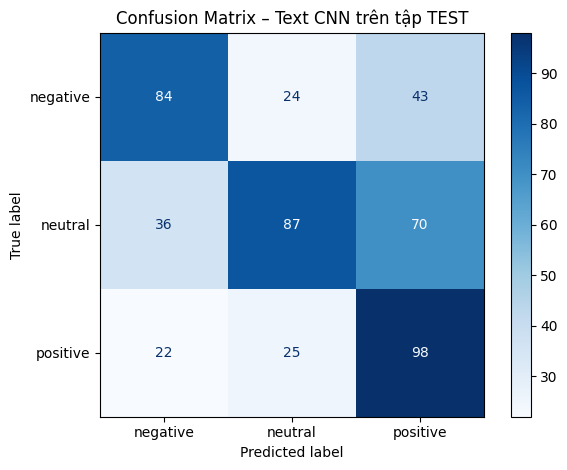

In [54]:
import numpy as np

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(6, 5))
disp.plot(
    cmap="Blues",          # tông xanh cho dễ nhìn
    values_format="d"      # hiển thị số nguyên
)
plt.title("Confusion Matrix – Text CNN trên tập TEST")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


test best ML model

In [55]:
test = pd.read_json("./test-preprocessed.json")
X_test_text = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)

In [56]:
y_test_enc = le.transform(y_test_text)


In [57]:
y_pred_enc = best_model.predict(X_test_text)
y_pred_enc = le.transform(y_pred_enc)


In [58]:
acc = accuracy_score(y_test_enc, y_pred_enc)
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

print(f"Accuracy trên test: {acc:.4f}")
print(f"Macro F1 trên test: {f1_macro:.4f}")

Accuracy trên test: 0.6196
Macro F1 trên test: 0.6212


In [59]:
report = classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=le.classes_
)
print(report)


              precision    recall  f1-score   support

    negative       0.64      0.64      0.64       151
     neutral       0.61      0.59      0.60       193
    positive       0.61      0.63      0.62       145

    accuracy                           0.62       489
   macro avg       0.62      0.62      0.62       489
weighted avg       0.62      0.62      0.62       489



<Figure size 600x500 with 0 Axes>

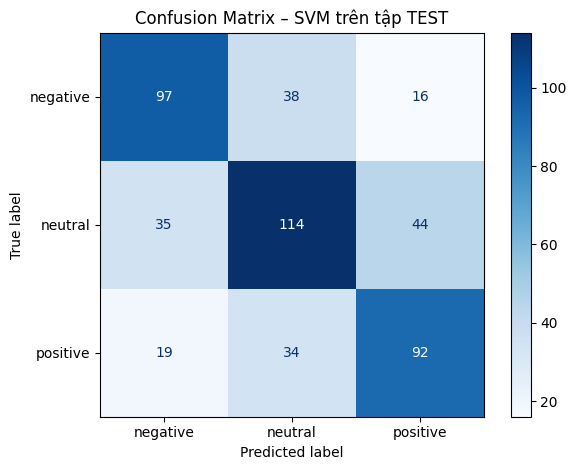

In [60]:
import numpy as np

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(6, 5))
disp.plot(
    cmap="Blues",          # tông xanh cho dễ nhìn
    values_format="d"      # hiển thị số nguyên
)
plt.title(f"Confusion Matrix – {best_name} trên tập TEST")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()
